# 05 · Módulo independientes: ¿qué pasa con quienes no tienen recibo de sueldo?

**Pregunta del Checkpoint 3:** muchos hogares pueden pagar, pero su ingreso no sale de un recibo de sueldo (monotributistas, autónomos, profesionales que facturan). ¿Cuántos son y qué riesgo agregan?

**Decisión:** analizarlos **en un módulo aparte**, sin modificar la base del estudio (que sigue exigiendo un asalariado con aportes). Así los resultados principales conservan su "pureza" y este módulo muestra el potencial adicional.

**Quiénes cuentan como independientes con aportes** (jefe/a o cónyuge ocupado):
- **Monotributistas** (EPH `PP05I` = 1) y **autónomos** (`PP05I` = 3), entre cuentapropistas y patrones.
- **Asalariados sin descuento jubilatorio que aportan por su cuenta** (`PP07H` = 2 y `PP07I` = 1): el caso típico de quien trabaja en relación de dependencia pero factura.
- El **monotributo social** (`PP05I` = 2) se mide aparte: la EPH casi no lo capta en los 3 mercados, así que no se puede estimar con confianza.

**Límite declarado:** no existe un índice oficial de ingresos de independientes comparable al de salarios registrados, así que su riesgo de cuota se analiza de forma descriptiva.

In [1]:
import sys, json, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
warnings.filterwarnings("ignore")

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

import config
import viz
import analysis as A
from affordability import ETAPAS, GBA, Producto, cargar_inquilinos, embudo, evaluar, parametros_mercado
from formato import fmt_cantidad, fmt_hogares, fmt_mes, fmt_monto, fmt_pct, fmt_decimal

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
pd.set_option("display.max_columns", 30)

con = duckdb.connect(str(config.DB_PATH), read_only=True)
m = parametros_mercado(con)
h = cargar_inquilinos(con)
base = Producto()
ev = evaluar(h, m, base)
ev["zona"] = A.grupo_geografico(ev)
K = json.loads((config.PROCESSED / "resultados" / "kpis.json").read_text(encoding="utf-8"))
RAMPA = LinearSegmentedColormap.from_list("azul", ["#eef4fc"] + viz.BLUE_RAMP)

def tinta_sobre(valor, vmin, vmax):
    """Texto blanco sobre celdas oscuras y tinta sobre celdas claras (según luminancia del color de fondo)."""
    r, g, b, _ = RAMPA((valor - vmin) / (vmax - vmin))
    return "#ffffff" if 0.2126 * r + 0.7152 * g + 0.0722 * b < 0.45 else viz.INK
print(f"UVA ${m['uva']:,.2f} ({m['fecha_uva']}) · dólar minorista ${m['tc']:,.2f} ({m['fecha_tc']})")
print(f"Inquilinos con ingreso declarado: {len(h)} observaciones de {h.hogar_id.nunique()} hogares encuestados · representan {fmt_hogares(h.peso.sum())}")

UVA $2,116.04 (2026-09-13) · dólar minorista $1,531.73 (2026-09-11)
Inquilinos con ingreso declarado: 2028 observaciones de 1504 hogares encuestados · representan 1,2 millones hogares


In [2]:
ind = A.modulo_independientes(h, m, base)
pd.Series(ind).to_frame("valor")

,valor
inquilinos_con_independiente_registrado,"251,156.00"
inquilinos_solo_independiente_sin_asalariado_formal,"174,335.75"
de_ellos_pasan_cuota_y_anticipo,"47,068.47"
elegibles_base,"154,793.14"
elegibles_aceptando_independientes,"201,273.11"
hogares_que_se_suman,"46,479.97"
ingreso_mediano_de_los_que_se_suman,"5,730,394.55"
inquilinos_con_monotributo_social,36.00
monotributo_social_pasan_cuota_y_anticipo,0.00


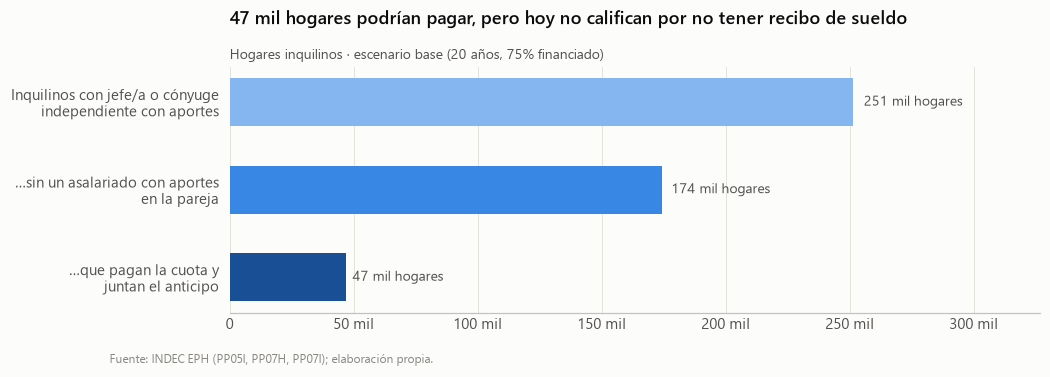

In [3]:
filas = [
    ("Inquilinos con jefe/a o cónyuge\nindependiente con aportes", ind["inquilinos_con_independiente_registrado"]),
    ("…sin un asalariado con aportes\nen la pareja", ind["inquilinos_solo_independiente_sin_asalariado_formal"]),
    ("…que pagan la cuota y\njuntan el anticipo", ind["de_ellos_pasan_cuota_y_anticipo"]),
]
fig, ax = plt.subplots(figsize=(9.5, 2.9))
y = np.arange(len(filas))[::-1]
ax.barh(y, [v for _, v in filas], color=["#86b6ef", "#3987e5", "#184f95"], height=0.55)
for yi, (_, v) in zip(y, filas):
    ax.text(v * 1.01 + 2000, yi, fmt_hogares(v), va="center", fontsize=9, color=viz.INK_2)
ax.set_yticks(y, [t for t, _ in filas])
ax.xaxis.set_major_formatter(viz.EJE_CANTIDAD)
ax.set_xlim(0, filas[0][1] * 1.3)
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
ax.set_title(f"{fmt_cantidad(ind['de_ellos_pasan_cuota_y_anticipo'])} hogares podrían pagar, pero hoy no califican por no tener recibo de sueldo")
viz.subtitle(ax, "Hogares inquilinos · escenario base (20 años, 75% financiado)")
viz.source(fig, "INDEC EPH (PP05I, PP07H, PP07I); elaboración propia.")
viz.save(fig, "05_independientes_embudo")
plt.show()

**Lectura:** 251 mil hogares inquilinos tienen a jefe/a o cónyuge trabajando como independiente con aportes. En 174 mil de ellos **no hay un asalariado con aportes en la pareja**, así que el banco no los ve. De esos, **47 mil pagan la cuota y juntan el anticipo**. Aceptarlos llevaría los elegibles de 155 mil a 201 mil con el producto base, y de 201 mil a 259 mil con el producto propuesto. Su ingreso mediano es de $ 5,7 millones por mes (pesos de agosto de 2026).

## ¿Qué tan estable es su ingreso?
La EPH vuelve a encuestar al mismo hogar en trimestres seguidos. Se compara cuánto cambia el ingreso real del hogar entre dos visitas, según la inserción laboral de jefe/a o cónyuge (todas las tenencias, para tener muestra suficiente).

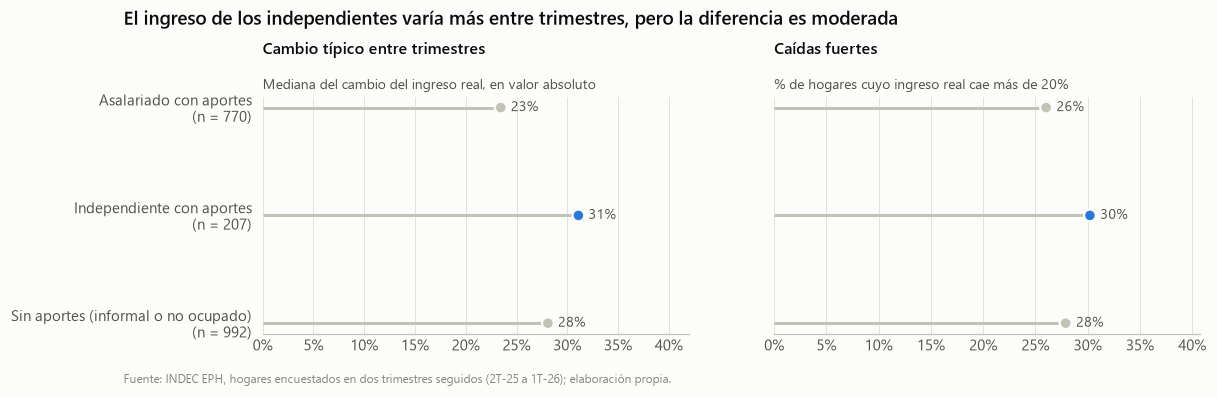

,insercion,muestra_hogares,cambio_absoluto_mediano_pct,pct_cae_mas_20,pct_sube_mas_20
0,Asalariado con aportes,770,23.40,26.00,31.20
1,Independiente con aportes,207,31.10,30.20,35.90
2,Sin aportes (informal o no ocupado),992,28.10,27.90,33.20


In [4]:
vol = A.volatilidad_ingresos(con)
orden = ["Asalariado con aportes", "Independiente con aportes", "Sin aportes (informal o no ocupado)"]
v = vol.set_index("insercion").loc[orden]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 2.8), sharey=True)
y = np.arange(len(v))[::-1]
for ax, col, titulo, bajada in [(a1, "cambio_absoluto_mediano_pct", "Cambio típico entre trimestres", "Mediana del cambio del ingreso real, en valor absoluto"),
                                (a2, "pct_cae_mas_20", "Caídas fuertes", "% de hogares cuyo ingreso real cae más de 20%")]:
    ax.hlines(y, 0, v[col], color=viz.BASELINE, lw=2)
    ax.scatter(v[col], y, s=60, color=[viz.CONTEXT_GRAY, viz.BLUE, viz.CONTEXT_GRAY], zorder=3, edgecolor=viz.SURFACE, linewidth=1.5)
    for yi, val in zip(y, v[col]):
        ax.text(val + 1, yi, fmt_pct(val, 0), va="center", fontsize=9, color=viz.INK_2)
    ax.set_xlim(0, v[col].max() * 1.35); ax.xaxis.set_major_formatter(viz.EJE_PCT)
    ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
    ax.set_title(titulo, fontsize=10.5); viz.subtitle(ax, bajada)
a1.set_yticks(y, [f"{i}\n(n = {n})" for i, n in zip(v.index, v.muestra_hogares)])
viz.titulo_figura(fig, "El ingreso de los independientes varía más entre trimestres, pero la diferencia es moderada")
viz.source(fig, "INDEC EPH, hogares encuestados en dos trimestres seguidos (2T-25 a 1T-26); elaboración propia.")
viz.save(fig, "05_volatilidad_ingresos")
plt.show()
vol.round(1)

**Lectura:** entre dos trimestres, el ingreso real de un hogar con **asalariado con aportes** cambia típicamente un 23%; con **independiente con aportes**, un 31%. Las caídas de más de 20% afectan al 26% y al 30%, respectivamente. Parte de esa variación es error de medición de la encuesta (afecta a todos los grupos por igual), así que lo relevante es la **diferencia**: existe, pero es moderada.

## Implicancias para una línea de independientes
- **Validación de ingresos:** 12 a 24 meses de facturación o de aportes, en lugar de recibo de sueldo.
- **Colchón de riesgo:** cuota hasta 20-25% del ingreso promedio de 12 meses (no del mejor mes) y seguro de desempleo o incapacidad.
- **Seguimiento:** tablero de mora separado para esta línea durante el primer año.
- **Monotributo social:** la EPH no permite dimensionarlo; queda como próximo paso con datos administrativos.

In [5]:
con.close()